## 베르누이 $ \to $ 이항변수 $ \to $ 표본비율, 분포, LLN
베르누이(성공 여부) $ \to $ 이항변수(성공 횟수, 합계)

이항변수의 정규분포 근사,

이항변수(성공 횟수, 합계) $ \to $ 표본비율(성공율, 평균)

표본비율(평균) 분포와 정규분포, CLT

표본비율과 대수의 법칙

In [35]:
# _lln_00.py
# law of large numbers, 오차의 크기

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import scipy as sci
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈. 필요한 통계 모듈만.
import statsmodels.api as sm                # 방대한 모델이라 개발자들이 많이 쓰는 모델 묶음.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭. 소문자 못읽어.
import matplotlib.pyplot as plt


### 파라메타 설정

In [36]:
# 필요한 파라메터 설정
# 표본 크기 지정, beg부터 end까지 stp 간격.
# 1000 부터 1000 간격으로 11000까지. 마지막은 포함하지 않으므로, 총 10개 경우임.
size_beg = 1000
size_end = 21000
size_stp = 1000

# number of iterations, monte carlo simulation given sample size.
n_itr = 1532    # 주어진 표본크기에서 n_itr 만큼 반복.실험.

# 임의변수 생성, 균등분포, 정규분포.
seed = 135678942   # 시드

# 균등분포 시작, 끝, 분산 = (b-a)^2/12 =약 225.33, 표편 약 15.01
p_pop = 0.37942

# bernouille X, 성공여부
x_avg = p_pop
x_var = p_pop*(1-p_pop)

# binomial Y, 성공횟수
n_try = 1952    # trial 횟수, 이게 표본 갯수에 해당.
y_avg = n_try * p_pop
y_var = n_try * p_pop * (1-p_pop)

# 정규분포 근사라면 이렇게.
mu_y = y_avg
sig_y = (y_var )**0.5

# phat
phat_avg = y_avg / n_try  # = p_pop
phat_var = y_var / (n_try**2)  # = p_pop(1-p_pop)/n_sze

# 정규분포라면 이렇게.
mu_phat = phat_avg
sig_phat = (phat_var )**0.5


### 베르누이 분포
 $ X_i \sim B(p) $이면,  
$$ E(X_i) = p , \quad  Var (X_i) = p(1-p) $$

$ p=0.6 $일 때,
$ \mu = 0.6, \ \sigma^2 = 0.24, \ \sigma = \sqrt{0.24} $.

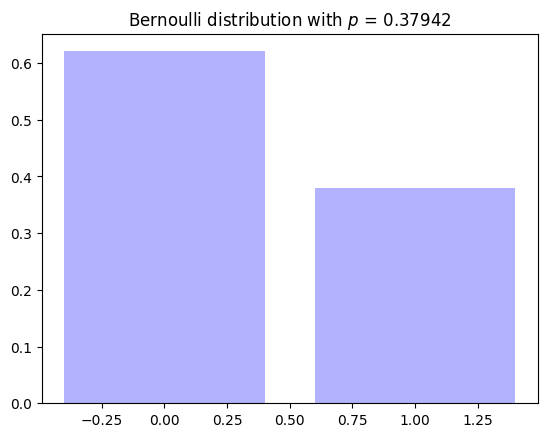

In [37]:
# 베루누이 변수
x = [0, 1] #np.arange(0, 2, 1)
p = [1-p_pop, p_pop]
plt.bar(x, p, color="blue", alpha =0.3, label="prob of success")
plt.title(f'Bernoulli distribution with $ p $ = {p_pop}')
#plt.legend() 막대마다 표시가 다르게...
plt.show()

### 이항분포
 $ Y_j \sim B(n,p) $이면,  
$$ E(Y_j) = np , \quad  Var (Y_j) = np(1-p) $$

$ n=532, \ p=0.6 $일 때,

$ \mu = 532 \times 0.6, \
\sigma^2 = 532 \times 0.24, \
\sigma = \sqrt{532\times 0.24} $.

### 정규분포 근사
for large $ n $,
$$ Y_j \approx N( \mu, SE^2) ,
\quad SE = \sqrt  n \times \sigma  
$$.

$ Y_j  $의
평균 $ n \times 0.6 $,
표준오차 $   \sqrt{ n }\times 0.4899  $.

$ n=100 \to SE = 4.899 $,  $ n=10000 \to SE = 48.99 $, ...  

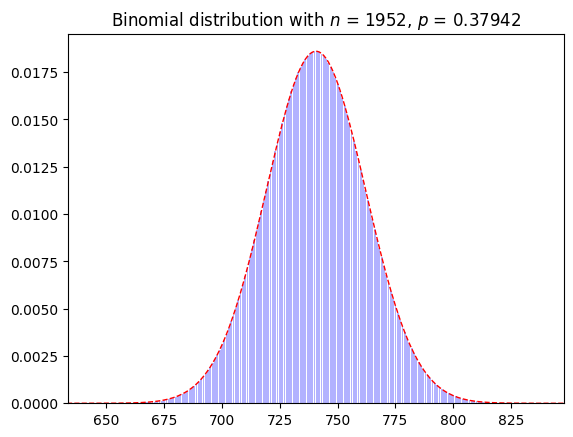

In [38]:
# 이항변수의 분포
y = np.arange(0, n_try+1, 1)
p_at_y = stats.binom.pmf(y, n_try, p_pop) # probability at y, number of successes
plt.bar(y, p_at_y, color="blue", alpha =0.3 ) #, label="prob of success") 밀도와 살짝 다름.
plt.title(f'Binomial distribution with $ n $ = {n_try}, $ p $ = {p_pop}')

d_at_y = stats.norm.pdf(y, mu_y, sig_y)   # density assumming normal distribution.
plt.plot(y, d_at_y, color="red", lw=1, linestyle="--")
plt.xlim(mu_y - 5*sig_y, mu_y + 5*sig_y)
# mean, var, 어디에 표시?
#plt.legend() 막대마다 표시가 다르게...
plt.show()

### $ \hat p $ (표본비율) 분포, $ Y_j /n $의 분포
 $ \hat p_j = { Y_j \over n  } $이면,  
$$ E( \hat p_j ) = p , \quad  Var (\hat p_j) = {p(1-p) \over n}$$

$ n=532, \ p=0.6 $일 때,

$ \mu =  0.6, \
\sigma^2 = { 0.24 \over 532 }, \
\sigma = \sqrt{ 0.24 \over 532 } \ \ \Leftarrow SE $.

### 정규분포 근사
for large $ n $,
$$ \hat p \approx N( \mu, SE^2) , \quad SE = {\sigma \over \sqrt n } $$.

$ \hat P $의 평균 0.6, 표준오차 $  0.4899 \over \sqrt{ n } $.

$ n=100 \to SE =0.04899 $,  $ n=10000 \to SE = 0.004899 $, ...  

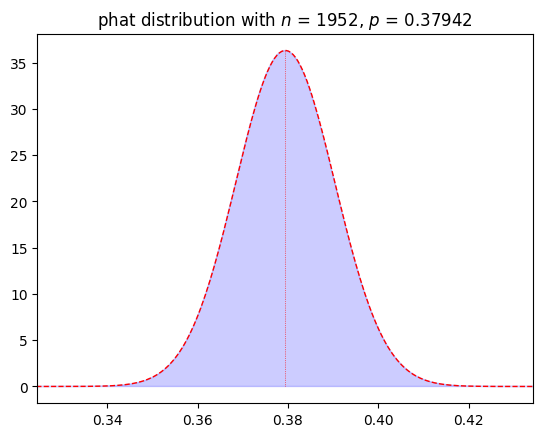

In [39]:
# phat의 분포, 이항변수 times 1/n
y = np.arange(0, n_try+1, 1)          # 위 셀.
ybyn = y / n_try                      # 0, 1 구간으로 조정
#print(ybyn)
p_at_ytismal = stats.binom.pmf(y, n_try, p_pop) / ( 1/n_try )  # prob->density

#plt.bar(ybyn, p_at_ytismal) #, color="blue", alpha =0.00 ) #, label="prob of success")
plt.plot(ybyn, p_at_ytismal, color="blue", alpha =0.00 ) #, label="prob of success")
plt.fill_between(ybyn, p_at_ytismal, color='blue', alpha=0.2)

dns_phat = stats.norm.pdf(ybyn, mu_phat, sig_phat )  # under normality
plt.plot(ybyn, dns_phat, color="red", lw=1, linestyle="--")

x_look = [mu_phat, mu_phat]                     # 평균 지점, 점선으로 표시
y_look = [0, stats.norm.pdf(mu_phat, mu_phat, sig_phat )]
plt.plot(x_look, y_look, color="red", linestyle="dotted", lw=0.5 )

plt.xlim(mu_phat - 5*sig_phat, mu_phat + 5*sig_phat )

plt.title(f'phat distribution with $ n $ = {n_try}, $ p $ = {p_pop}')

# mean, var, 어디에 표시?
#plt.legend() 막대마다 표시가 다르게...
plt.show()

### CLT, LLN 반복실험, 이항분포
n 크기 마다 수 천 번 반복 --> 분포 히스토그램
n 크기 늘려서 동일 실험 반복 --> 히스토그램 반복 생성

표본크기가 증가하면 정규분표처럼 보여진다. 합계도...

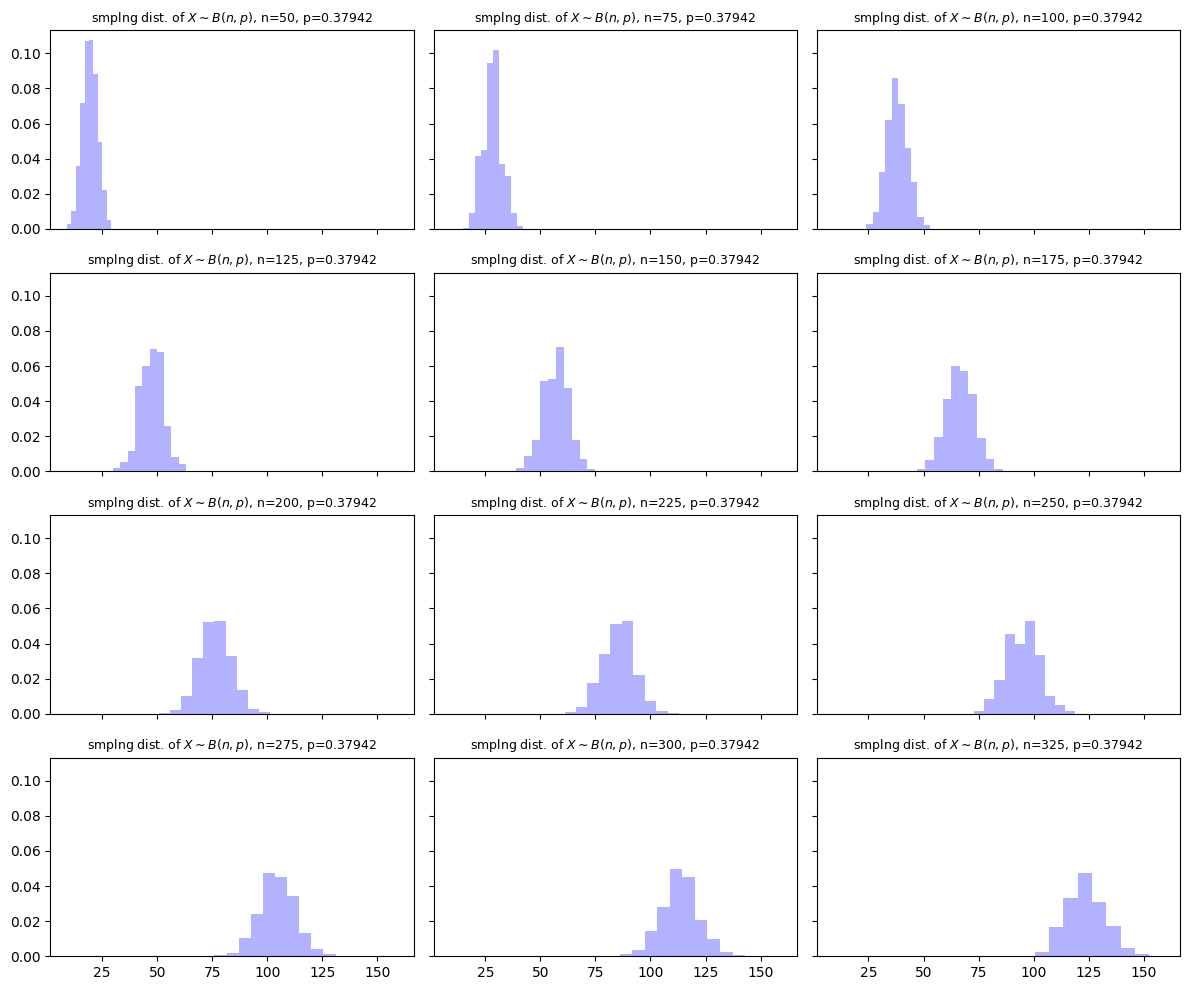

In [40]:
# 1. 데이터 준비. 읽기. 생성. random number
rng = np.random.default_rng(seed)
smpls = np.arange(50, 350, 25) # 다양한 표본 크기 트라이...

# 2. 그림(서브플롯) 생성 준비.
sub_n = len(smpls) # 플롯 갯수, 시도하는 표본 크기
sub_c = 3  # 열 갯수
sub_r = int(np.ceil(sub_n/sub_c))   # 행 갯수
fig_s = 12            # 전체 그림 가로
box_w = fig_s/sub_c            # 플롯 가로 3
box_h = box_w*(10/16)          # 플롯 세로, 황긍비 스타일

fig, axes = plt.subplots(nrows= sub_r, ncols= sub_c, figsize=(sub_c*box_w, sub_r*box_h), sharex=True, sharey=True)

# 2.1. 2차원 배열인 axes를 1차원(10개)으로 평평하게 폄.
axes = axes.flatten()

# 1.1. 계산 결과를 담을 리스트. 여기에 표본 평균을 담음.
## 표본 크기에서 모의실험 결과 정리. 표본크기, 평균의 평균, 평균의 표준편차
muhat_rslt = []

# 3. 반복문 실행. 이건 일종의 따블 반복문. k, i,
for sub_i, k in enumerate(smpls) : # 다양한 표본 크기 트라이... np.arange(size_beg, size_end, size_stp)):
    # 서브플롯 순서를 sub_i로 받음.
    # for k in np.arange(size_beg, size_end, size_stp):
    # # a에서 b까지 c씩 증가, 끝은 포함하지 않음. 인텍스 k.
    n_smpl = k

    # 각 서브플롯 선택, enumerate 인덱스 sub_i로 받음.
    ax = axes[sub_i]

    # 표본 크기 고정. 평균 관측치 묶음. 234회 => 평균치 234개, n_itr 개
    muhat = []

    # 반복문(인덱스 k) 내 반복문(인덱스 i)임.
    for i in np.arange(0, n_itr, 1) :  # 0에서 itr까지 1씩 증가
        # x = rng.normal(loc=mu, scale=sig, size=n_smpl)  # obs tbg
        x = rng.binomial(k, p_pop)
        muhat.append(np.mean(x)) # 매회 muhat 계산, 반복할 때 추가, append.

    # 서브플롯 생성(반복문 i 바깥, 반복문 k 내부)
    ax.hist(muhat, color="blue", density='True', alpha=0.3)    # n_smpl = 1000, n_itr = 2345 반복시 평균 분포 히스토그램(상자그림 가능)
    ax.set_title(f'smplng dist. of $ X \\sim B(n, p) $, n={k}, p={p_pop}', fontsize=9) # n_smpl 별 서브플롯
    #plt.show()

    # 서브 계산(인덱스 k): 표본 크기, 평균, 표준오차, 쌓아 올림.
    muhat_mean = np.mean(muhat)     # 표본 크기 고정, n_itr 반복 평균치의 평균. for i 바깥임. 끝난 후.
    muhat_std = np.std(muhat, ddof=1)
    muhat_rslt.append( [n_smpl, muhat_mean, muhat_std] )  # 표본 크기마다 계산된 통계치 쌓음.
                                                             # n의 크기와 평균의 평균, 평균의 표준편차
                                                             # 최종 산출물, 관심 대상.
    # 여기까지 인덱스 k 진행중. 인덱스 i 벗어남.
    #plt.title('Sampling distributions of $ \hat\mu $ ')
# 인텍스 k 벗어남. 최종 결과들.
# 4. 서브플롯들끼리 겹치지 않게 여백 자동 조정
# 표본 크기가 증가하면 히스토그램이 중심으로 붕괴한다. 확인.
plt.tight_layout()
plt.show()


### 한 화면에 구현
표본 크기가 늘어날 때, 분포의 변화

이항분포 $ \to $ 정규분포

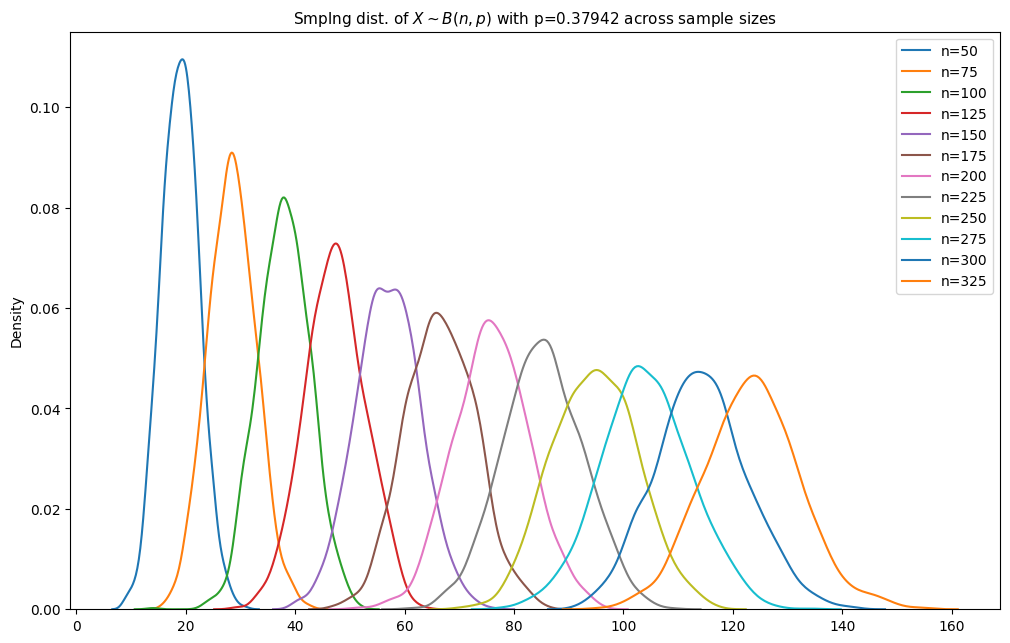

In [44]:
import seaborn as sns
# 1. 데이터 준비. 읽기. 생성. random number

#rng = np.random.default_rng(seed) 위 셀 중복.
smpls = np.arange(50, 350, 25) # 다양한 표본 크기 트라이... 반복,

# 2. 그림(서브플롯) 생성 준비. 위 셀 중복
# sub_n = len(smpls) # 플롯 갯수, 시도하는 표본 크기
# sub_c = 3  # 열 갯수
# sub_r = int(np.ceil(sub_n/sub_c))   # 행 갯수
# fig_s = 12                     # 전체 그림 가로
# box_w = fig_s/sub_c            # 플롯 가로 3
# box_h = box_w*(10/16)          # 플롯 세로, 황긍비 스타일

plt.figure( figsize=( 16*0.75, 10*0.75) )   # 황금비 스타일로 전체 차트 사이즈 지정.
                                 # 서브 플롯 대신 하나의 빅 차트로 묶음
muhat_rslt = []

# 3. 반복문 실행. 이건 일종의 따블 반복문. k, i,
for sub_i, k in enumerate(smpls) : # 다양한 표본 크기 트라이... np.arange(size_beg, size_end, size_stp)):
    n_smpl = k
    muhat = []

    # 반복문(인덱스 k) 내 반복문(인덱스 i)임.
    for i in np.arange(0, n_itr, 1) :  # 0에서 itr까지 1씩 증가
        x = rng.binomial(k, p_pop)
        muhat.append(np.mean(x)) # 매회 muhat 계산, 반복할 때 추가, append.

    # 서브플롯 생성(반복문 i 바깥, 반복문 k 내부)
    sns.kdeplot(x=muhat, label=f"n={k}" )  # n_smpl = 1000, n_itr = 2345 반복시 평균 분포 히스토그램-커브-)
#    plt.hist(muhat, color="blue", density='True', alpha=0.3)
    plt.title(f'Smplng dist. of $ X \\sim B(n,p) $ with p={p_pop} across sample sizes', fontsize=11)
    plt.legend()
    # 여기까지 인덱스 k 진행중. 인덱스 i 벗어남.
# 인텍스 k 벗어남. 최종 결과들.
plt.show()


### CLT, LLN 반복실험, $ \hat p $ 분포
n 크기 마다 수 천 번 반복 --> 분포 히스토그램
n 크기 늘려서 동일 실험 반복 --> 히스토그램 반복 생성

표본 크기가 증가하면 정규분포처럼 보여진다.
표본 비율이.
물론 이것은 평균이다. 동일하다. CLT   

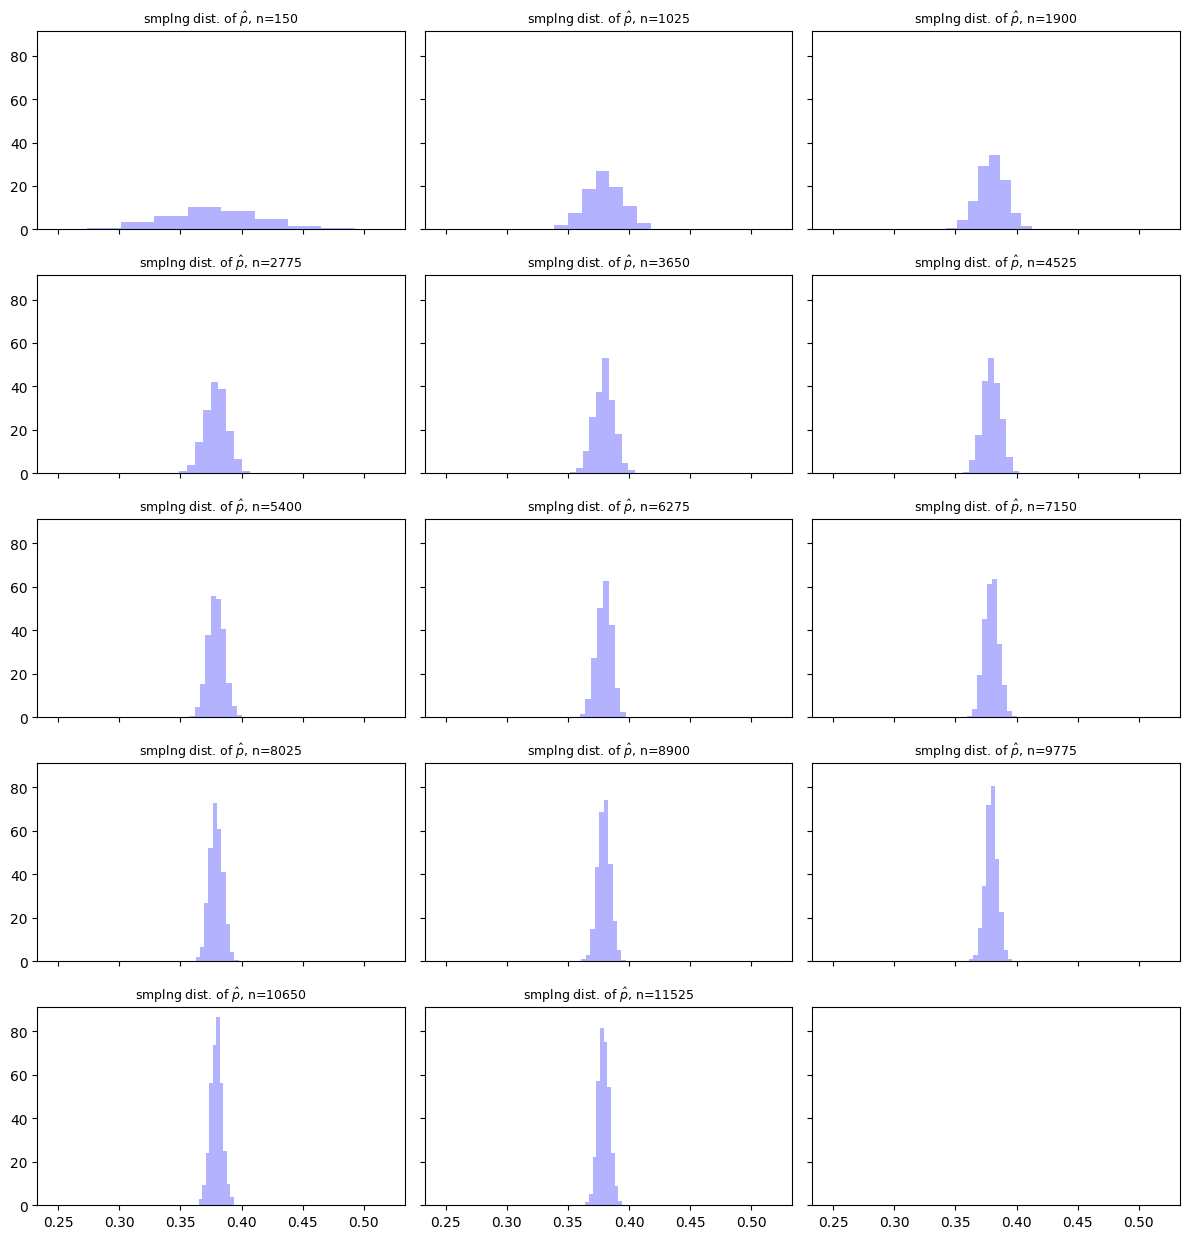

In [45]:
# 위와 같은 것인데, phat으로, 즉 1/n을 곱한 것임.
# 1. 데이터 준비. 읽기. 생성. random number
rng = np.random.default_rng(seed)
smpls = np.arange(150, 12350, 875) # 다양한 표본 크기 트라이...

# 2. 그림(서브플롯) 생성 준비.
sub_n = len(smpls) # 플롯 갯수, 시도하는 표본 크기
sub_c = 3  # 열 갯수
sub_r = int(np.ceil(sub_n/sub_c))   # 행 갯수
fig_s = 12            # 전체 그림 가로
box_w = fig_s/sub_c            # 플롯 가로 3
box_h = box_w*(10/16)          # 플롯 세로, 황긍비 스타일

fig, axes = plt.subplots(nrows= sub_r, ncols= sub_c, figsize=(sub_c*box_w, sub_r*box_h), sharex=True, sharey=True)

# 2.1. 2차원 배열인 axes를 1차원(10개)으로 평평하게 폄.
axes = axes.flatten()

# 1.1. 계산 결과를 담을 리스트. 여기에 표본 평균을 담음.
## 표본 크기에서 모의실험 결과 정리. 표본크기, 평균의 평균, 평균의 표준편차
muhat_rslt = []

# 3. 반복문 실행. 이건 일종의 따블 반복문. k, i,
for sub_i, k in enumerate(smpls) : # 다양한 표본 크기 트라이... np.arange(size_beg, size_end, size_stp)):
    # 서브플롯 순서를 sub_i로 받음.
    # for k in np.arange(size_beg, size_end, size_stp):
    # # a에서 b까지 c씩 증가, 끝은 포함하지 않음. 인텍스 k.
    n_smpl = k

    # 각 서브플롯 선택, enumerate 인덱스 sub_i로 받음.
    ax = axes[sub_i]

    # 표본 크기 고정. 평균 관측치 묶음. 234회 => 평균치 234개, n_itr 개
    muhat = []

    # 반복문(인덱스 k) 내 반복문(인덱스 i)임.
    for i in np.arange(0, n_itr, 1) :  # 0에서 itr까지 1씩 증가
        # x = rng.normal(loc=mu, scale=sig, size=n_smpl)  # obs tbg
        x = rng.binomial(k, p_pop) / k    # 성공횟수를 성공 비율로.
        muhat.append(np.mean(x)) # 매회 muhat 계산, 반복할 때 추가, append.

    # 서브플롯 생성(반복문 i 바깥, 반복문 k 내부)
    ax.hist(muhat, color="blue", density='True', alpha=0.3)    # n_smpl = 1000, n_itr = 2345 반복시 평균 분포 히스토그램(상자그림 가능)
    ax.set_title(f'smplng dist. of $ \\hat p $, n={k}', fontsize=9) # n_smpl 별 서브플롯
    #plt.show()

    # 서브 계산(인덱스 k): 표본 크기, 평균, 표준오차, 쌓아 올림.
    muhat_mean = np.mean(muhat)     # 표본 크기 고정, n_itr 반복 평균치의 평균. for i 바깥임. 끝난 후.
    muhat_std = np.std(muhat, ddof=1)
    muhat_rslt.append( [n_smpl, muhat_mean, muhat_std] )  # 표본 크기마다 계산된 통계치 쌓음.
                                                             # n의 크기와 평균의 평균, 평균의 표준편차
                                                             # 최종 산출물, 관심 대상.
    # 여기까지 인덱스 k 진행중. 인덱스 i 벗어남.
    #plt.title('Sampling distributions of $ \hat\mu $ ')
# 인텍스 k 벗어남. 최종 결과들.
# 4. 서브플롯들끼리 겹치지 않게 여백 자동 조정
# 표본 크기가 증가하면 히스토그램이 중심으로 붕괴한다. 확인.
plt.tight_layout()
plt.show()


### 한 화면에

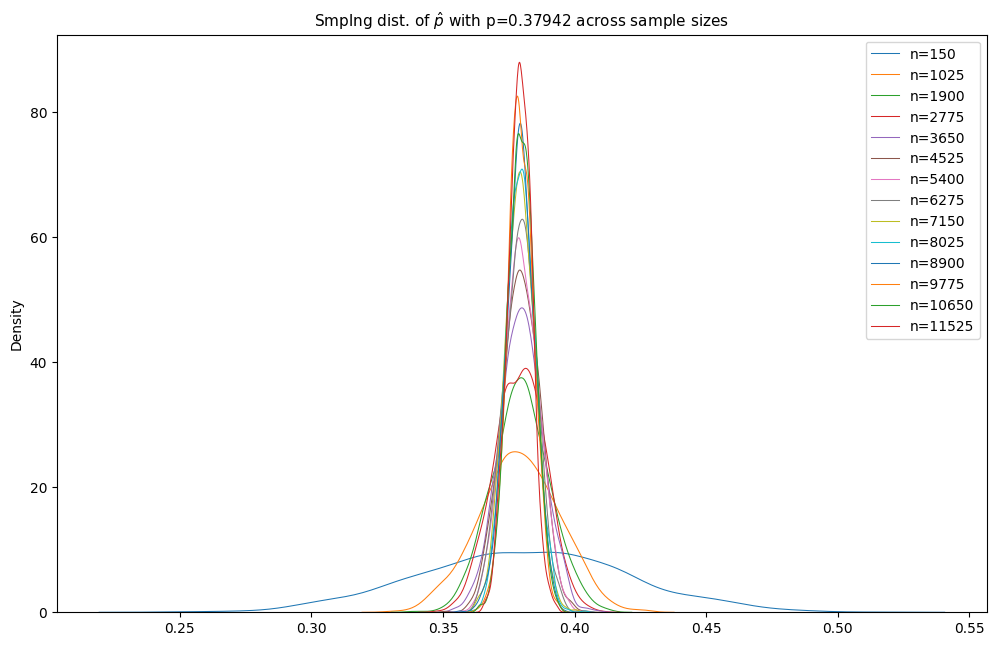

In [50]:
# 위와 같은 것인데, phat으로, 즉 1/n을 곱한 것임.
# 1. 데이터 준비. 읽기. 생성. random number
# rng = np.random.default_rng(seed)
smpls = np.arange(150, 12350, 875) # 다양한 표본 크기 트라이...

# 2. 그림(서브플롯) 생성 준비.
# sub_n = len(smpls) # 플롯 갯수, 시도하는 표본 크기
# sub_c = 3  # 열 갯수
# sub_r = int(np.ceil(sub_n/sub_c))   # 행 갯수
# fig_s = 12            # 전체 그림 가로
# box_w = fig_s/sub_c            # 플롯 가로 3
# box_h = box_w*(10/16)          # 플롯 세로, 황긍비 스타일

plt.figure( figsize=( 16*0.75, 10*0.75) )   # 황금비 스타일로 전체 차트 사이즈 지정.
                                 # 서브 플롯 대신 하나의 빅 차트로 묶음
muhat_rslt = []

# 3. 반복문 실행. 이건 일종의 따블 반복문. k, i,
for sub_i, k in enumerate(smpls) : # 다양한 표본 크기 트라이... np.arange(size_beg, size_end, size_stp)):
    n_smpl = k
    muhat = []

    # 반복문(인덱스 k) 내 반복문(인덱스 i)임.
    for i in np.arange(0, n_itr, 1) :  # 0에서 itr까지 1씩 증가
        x = rng.binomial(k, p_pop) / k    # 성공횟수를 성공 비율로.
        muhat.append(np.mean(x)) # 매회 muhat 계산, 반복할 때 추가, append.

    # 서브플롯 생성(반복문 i 바깥, 반복문 k 내부)
    sns.kdeplot(x=muhat, lw=0.75, label=f"n={k}" )  # n_smpl = 1000, n_itr = 2345 반복시 평균 분포 히스토그램-커브-)
#    plt.hist(muhat, color="blue", density='True', alpha=0.3)
    plt.title(f'Smplng dist. of $ \\hat p $ with p={p_pop} across sample sizes', fontsize=11)
    plt.legend()
    # 여기까지 인덱스 k 진행중. 인덱스 i 벗어남.
# 인텍스 k 벗어남. 최종 결과들.
plt.show()


### 그래프에서 확인할 수 있는 것
이항변수(합계, 성공횟수)
표본 크기가 증가하면, 점점 정규분포처럼 보인다.
물론 평균, 분산은 증가함. <== 합계.
히스토그램 우측으로 이동하면서 펼처짐.

표본비율(평균, 성공비율)
표본 크기가 증가하면 점점 정규분포처럼 보인다.
물론 평균은 일정, 분산은 감소함. <== 평균.
히스토그램은 제자리에 있으면서 점점 폭이 좁아진다.
